# P2.3 · Matrices and learned linear layers

**Maths fundamentals for transformers · Tiny Transformer**

The model must turn its feature vectors into useful queries, keys, values, and hidden features.

**You will be able to:** A learned linear layer applies one dot product per output feature, then adds its bias, using the same weights at every position.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

How do many dot products make new features?

Write down your prediction before running the calculation.

A linear layer maps 3 inputs to 2 outputs. Count its weights and biases together.

## Work the numbers

1. Input x = [2, 0, 1]

2. Weight entries: [1, 3, −1] and [0, 2, 1]

3. Dot products [1, 1] + bias [0, 1]

4. Output [1, 2]; stored W shape [2 × 3]

$$Y=XW^{\mathsf T}+b,\quad [T,D]\,[D,O]\to[T,O]$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
x = torch.tensor([2., 0., 1.])
W = torch.tensor([[1., 3., -1.], [0., 2., 1.]])
b = torch.tensor([0., 1.])
y = x @ W.T + b
print("weight", tuple(W.shape), "transpose", tuple(W.T.shape))
print("output", y.tolist())
torch.testing.assert_close(y, F.linear(x, W, b))
X = torch.stack((x, x * 2))
print("same weights at both positions", (X @ W.T + b).tolist())

weight (2, 3) transpose (3, 2)
output [1.0, 2.0]
same weights at both positions [[1.0, 2.0], [2.0, 3.0]]


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

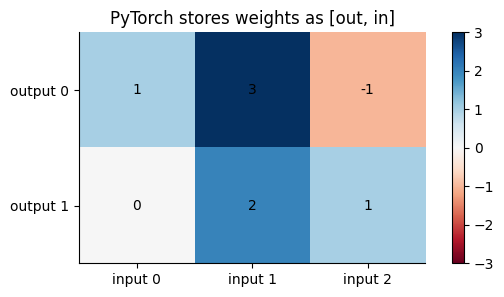

In [4]:
W = np.array([[1., 3., -1.], [0., 2., 1.]])
plt.imshow(W, cmap="RdBu", vmin=-3, vmax=3)
for i in range(2):
    for j in range(3): plt.text(j,i,f"{W[i,j]:g}",ha="center",va="center",color="black")
plt.xticks(range(3), ["input 0", "input 1", "input 2"])
plt.yticks(range(2), ["output 0", "output 1"])
plt.title("PyTorch stores weights as [out, in]"); plt.grid(False); plt.colorbar(); plt.show()

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **inside-attention**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"config":{"vocab_size":65,"block_size":32,"d_model":28,"n_head":2,"d_ff":56,"n_layer":1}}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
c=recorded["config"]; D=c["d_model"]; layer=torch.nn.Linear(D,3*D); print("QKV weight",tuple(layer.weight.shape),"learned count",sum(p.numel() for p in layer.parameters())); print("This layer is newly initialized; the dimensions match the recorded model.")

QKV weight (84, 28) learned count 2436
This layer is newly initialized; the dimensions match the recorded model.


## A common trap

Transpose changes how axes are arranged. It is not an inverse. Bias broadcasts over positions, not across unrelated feature sizes.

### ✋ Your turn

A linear layer maps 3 inputs to 2 outputs. Count its weights and biases together.

In [7]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert int(answer) == 8, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = 8

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert int(answer) == 8, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: 8


## Connect the dots

A learned linear layer applies one dot product per output feature, then adds its bias, using the same weights at every position.

Next: token and position embeddings.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.